# This notebook is used to visualy inspect the quality of the ground truths and the proposed regions of interest RoI for the masked R-CNN

In [1]:
dataset_filepath = "/net/vdesk/data2/penchev/project_data/rgz_test"
images_train_filepath = "images"
proposals_train_filepath = "proposals"
annotations_path = "annotations.json"

# Load the json file containing the cutout metadata and proposed RoIs

In [2]:
import json
import os

annotations_path = os.path.join(dataset_filepath, annotations_path)
with open(annotations_path, "r") as f:
    annotations = json.load(f)

In [3]:
from tqdm import tqdm

total_images = len(annotations["images"])
MCS_num = 0
images_with_MCS = set()
SCS_num = 0
images_with_SCS = set()

anns = annotations["annotations"]

for ann in tqdm(anns):
    if ann["category_id"] == 2:
        MCS_num += 1
        images_with_MCS.add(ann["image_id"])
    elif ann["category_id"] == 1:
        SCS_num += 1
        images_with_SCS.add(ann["image_id"])

100%|██████████| 3157/3157 [00:00<00:00, 1383060.13it/s]


In [4]:
print(f"MCS: {MCS_num}, SCS: {SCS_num}")
print(f"Images with MCS: {len(images_with_MCS)}, Images with SCS: {len(images_with_SCS)}")
print(f"Total images: {total_images}")

MCS: 130, SCS: 3027
Images with MCS: 122, Images with SCS: 420
Total images: 420


In [13]:
print(annotations['annotations'][1])

{'id': 2, 'image_id': 1, 'category_id': 1, 'bbox': [16.0, 136.0, 53.0, 158.0], 'area': 337.0, 'segmentation': {'size': [300, 300], 'counts': 'ej42Y94L3N2N1O0O0010O101N2M2O1O1O1O0101M2O02O0000O100O1O1K5000O20O0010O0O2N2N3LkFMoVX2'}, 'iscrowd': 0, 'instance_positions': [[36, 146]]}


In [8]:
# Shuffle the images with MCS and SCS
import random
random.seed(43)  # For reproducibility
images_with_MCS = list(images_with_MCS)
images_with_SCS = list(images_with_SCS)
random.shuffle(images_with_MCS)
random.shuffle(images_with_SCS)

# Pick 7 MCS and 1 SCS images for inspection
num_MCS_to_inspect = min(7, len(images_with_MCS))
num_SCS_to_inspect = min(1, len(images_with_SCS))
images_to_inspect = images_with_MCS[:num_MCS_to_inspect] + images_with_SCS[:num_SCS_to_inspect]
print(f"Images to inspect: {images_to_inspect}")

Images to inspect: [16, 175, 144, 256, 147, 288, 133, 68]


# Display the images with the proposed RoIs and ground truth annotations

In [6]:
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import numpy as np
import os

print(f"Loading COCO annotations from {annotations_path}...")
coco = COCO(annotations_path)

def get_image_by_id(annotations: dict, image_id: int) -> dict:
    """
    Retrieve the image element from the annotations JSON by image ID.
    
    :param annotations: The annotations dictionary containing 'images' list
    :param image_id: The ID of the image to find
    :return: Dictionary containing image metadata (id, file_name, width, height, metadata)
    :raises ValueError: If image_id is not found
    """
    for image in annotations['images']:
        if image['id'] == image_id:
            return image
    raise ValueError(f"Image with id {image_id} not found in annotations")

def plot_image_with_boxes_proposals(annotations: dict, annotations_path: str, id: int):
    """
    Plot an image with bounding boxes overlaid.
    
    :param image_path: Path to the image file
    :param boxes: Array of bounding boxes in the format [x_min, y_min, x_max, y_max]
    """
    image_info = get_image_by_id(annotations, id)
    image_file_name = image_info['file_name']
    proposals = image_file_name.replace(".png", ".npz")
    image_path = os.path.join(dataset_filepath, images_train_filepath, image_file_name)
    proposals_path = os.path.join(dataset_filepath, proposals_train_filepath, proposals)

    # Get the data for the plotting of the images
    proposal_boxes = np.load(proposals_path)['boxes']

    components = image_info['metadata']['candidates']['grouping']['components']
    sources = image_info['metadata']['candidates']['grouping']['sources']

    all_poistions = []
    for component in components:
        xy_list = component['xy']
        all_poistions.append(xy_list)

    # Load COCO annotations
    ann_ids = coco.getAnnIds(imgIds=[id], iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    
    # COCO format: [x_min, y_min, x_max, y_max]
    # (x_min, y_min) is the top-left corner
    # (x_max, y_max) is the bottom-right corner
    gt_boxes = [ann['bbox'] for ann in anns]
    
    # Get segmentation masks
    segs = [ann['segmentation'] for ann in anns]

    # Get positions of the components in the GT box
    instance_positions = [ann['instance_positions'] for ann in anns]

    # Get category IDs
    category_ids = [ann['category_id'] for ann in anns]

    SCS_color = 'cyan'  # category id 1
    MCS_color = 'red'   # category id 2
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    img = plt.imread(image_path)
    
    # Plot GT boxes and segmentation on ax[0]
    ax[0].imshow(img)
    for i, box in enumerate(gt_boxes):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        edgecolor = SCS_color if category_ids[i] == 1 else MCS_color
        rect = plt.Rectangle((x_min, y_min), width, height, edgecolor=edgecolor, facecolor='none', linewidth=2)
        ax[0].add_patch(rect)

    for i, seg in enumerate(segs):
        if isinstance(seg, list):  # Polygon segmentation
            print(f"Polygon segmentation with {len(seg)} polygons")
            for polygon in seg:
                poly = np.array(polygon).reshape((-1, 2))
                ax[0].fill(poly[:, 0], poly[:, 1], alpha=0.3, color='black')

        if isinstance(seg, dict) and 'counts' in seg:  # RLE segmentation
            mask = coco.annToMask(anns[i])  # Get binary mask from current annotation RLE
            seg_color = SCS_color if category_ids[i] == 1 else MCS_color
            masked = np.ma.masked_where(mask == 0, mask)
            cmap = plt.get_cmap('Oranges_r') if seg_color == MCS_color else plt.get_cmap('Blues_r')
            ax[0].imshow(masked, alpha=0.8, cmap=cmap)

    for i, ip in enumerate(instance_positions):
        color = SCS_color if category_ids[i] == 1 else MCS_color
        for pos in ip:
            ax[0].annotate(f"{i}", tuple(pos), color=color, fontsize=15, ha='center')

    for pos in all_poistions:
        ax[0].scatter(pos[0], pos[1], color='yellow', marker='*', s=100, label='Component Position')

    ax[0].set_title("GT Boxes and Segmentation")

    ax[1].imshow(img)
    print(f"Plotting {len(proposal_boxes)} proposal boxes on image {image_file_name}")

    for i, box in enumerate(proposal_boxes):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='red', facecolor='none', linewidth=2, label='Proposed Box' if i == 0 else "")
        ax[1].add_patch(rect)

    ax[1].set_title("Image with Bounding Boxes")
    plt.show()

Loading COCO annotations from /net/vdesk/data2/penchev/project_data/rgz_test/annotations.json...
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


Plotting 511 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000016_RA162.642405_DEC54.060732.png


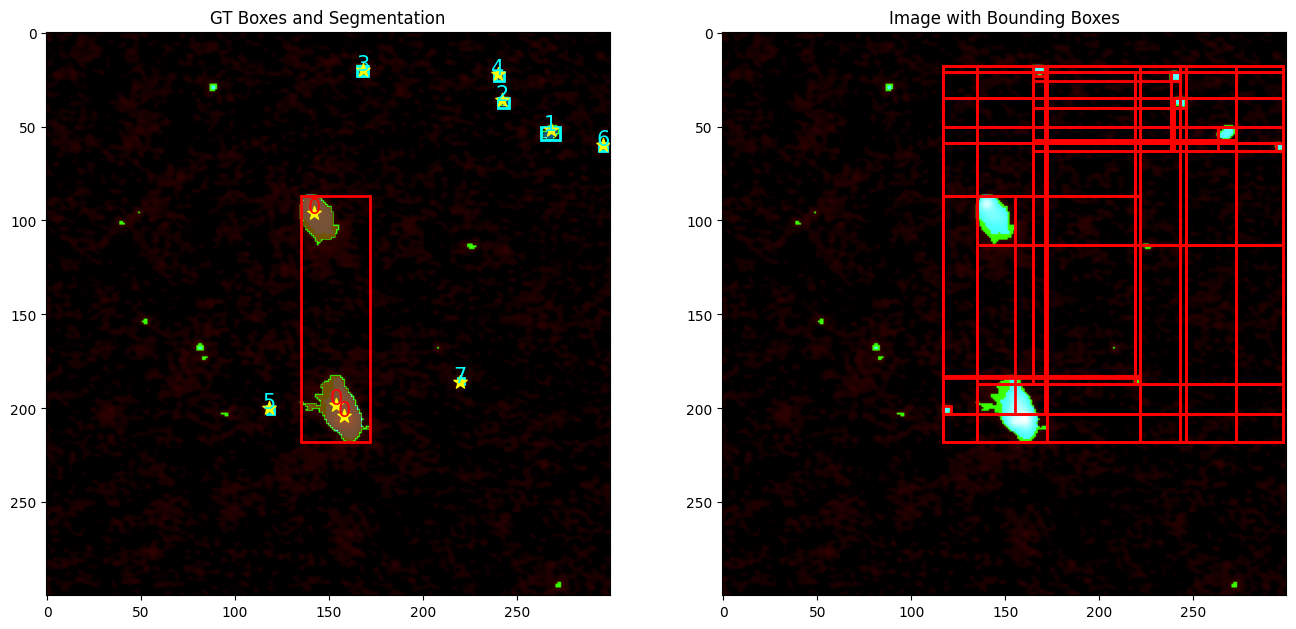

Plotting 1023 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000175_rotated_angle180_RA165.323084_DEC53.849255.png


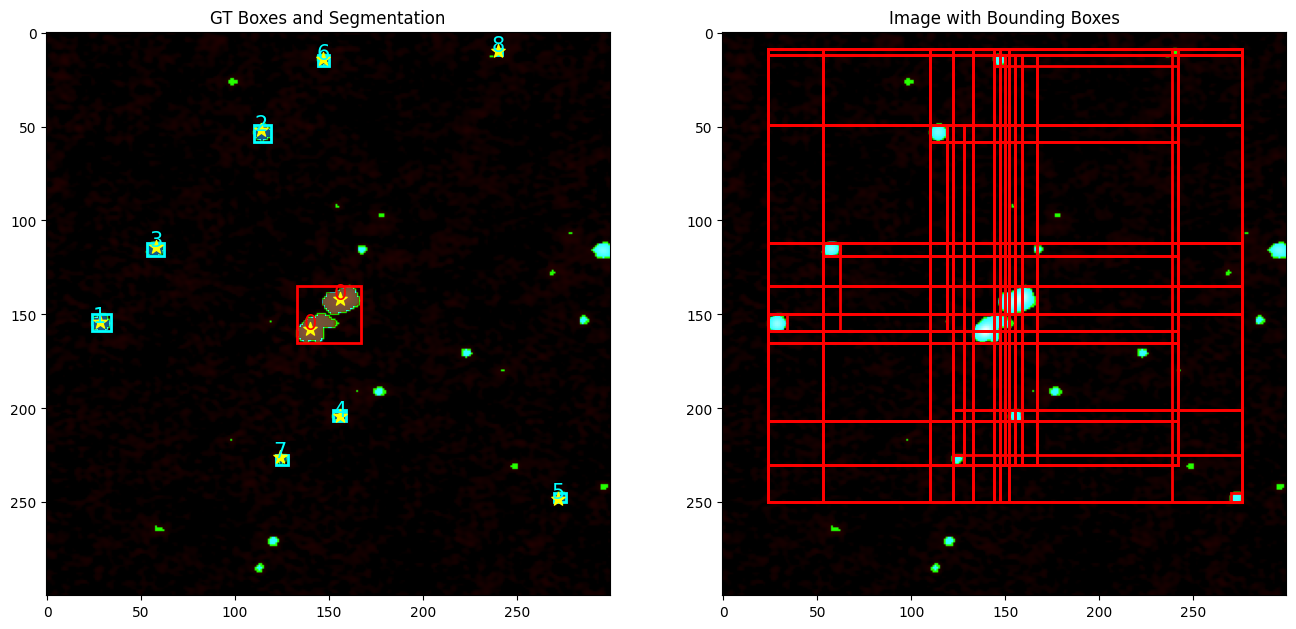

Plotting 511 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000144_rotated_angle135_RA164.403856_DEC55.852801.png


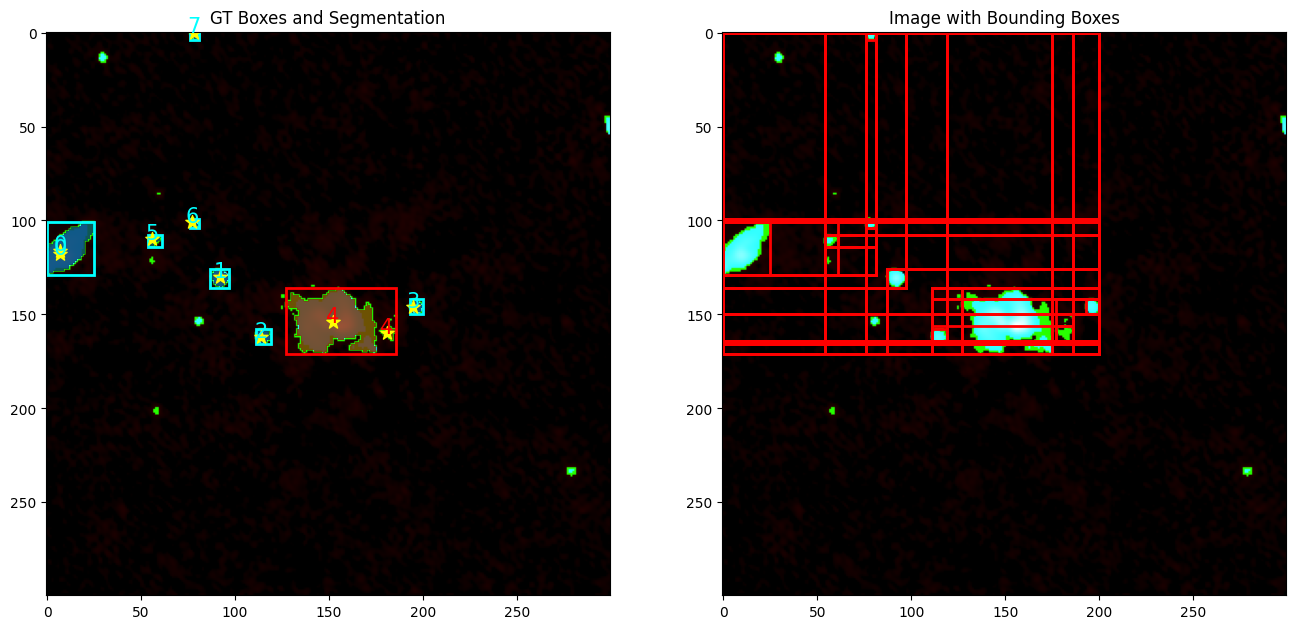

Plotting 511 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000256_RA164.509839_DEC50.591453.png


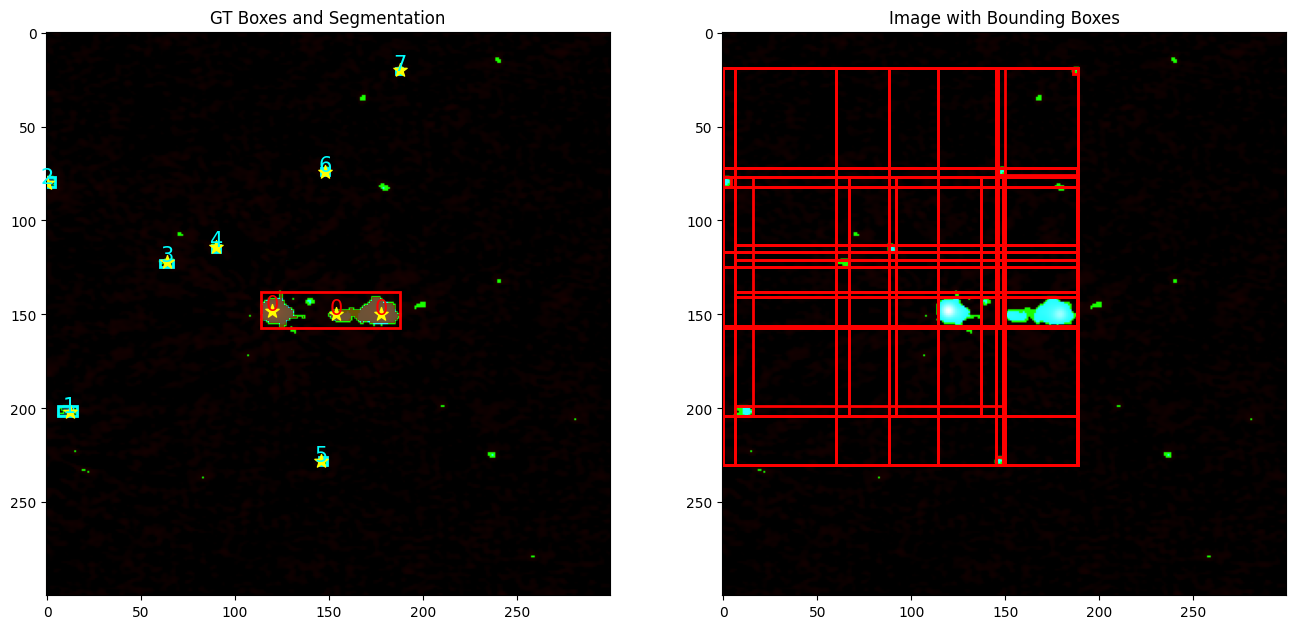

Plotting 1023 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000147_rotated_angle45_RA164.773417_DEC55.87387.png


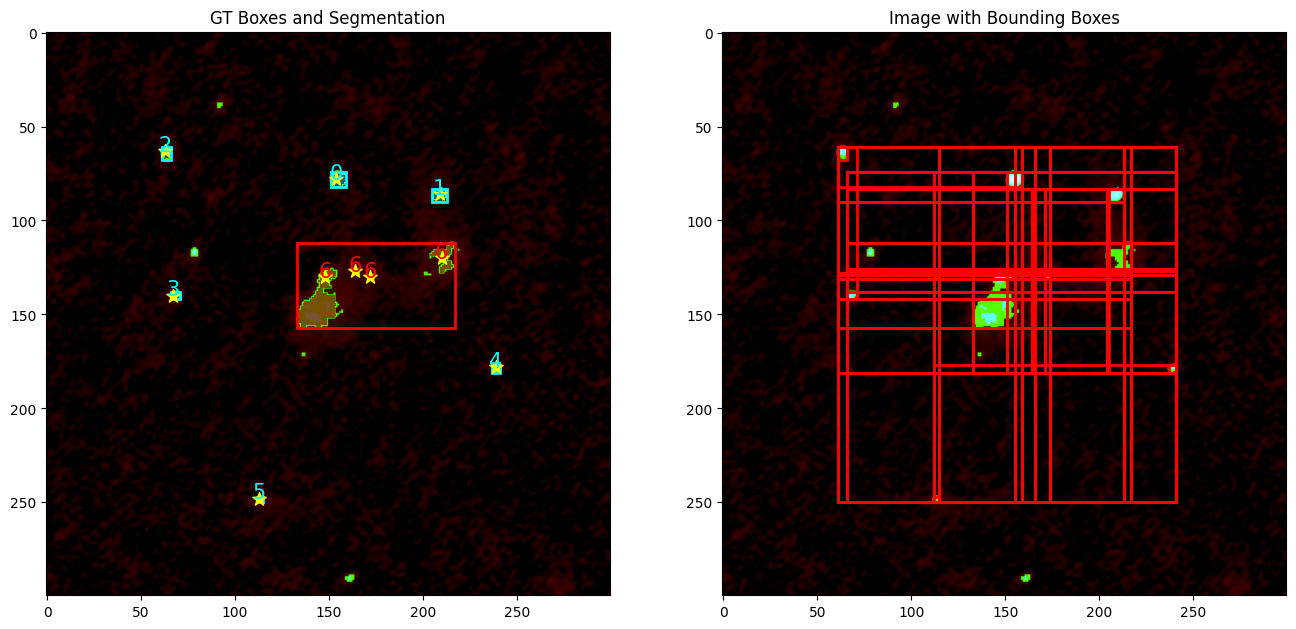

Plotting 511 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000288_rotated_angle90_RA165.514813_DEC49.874513.png


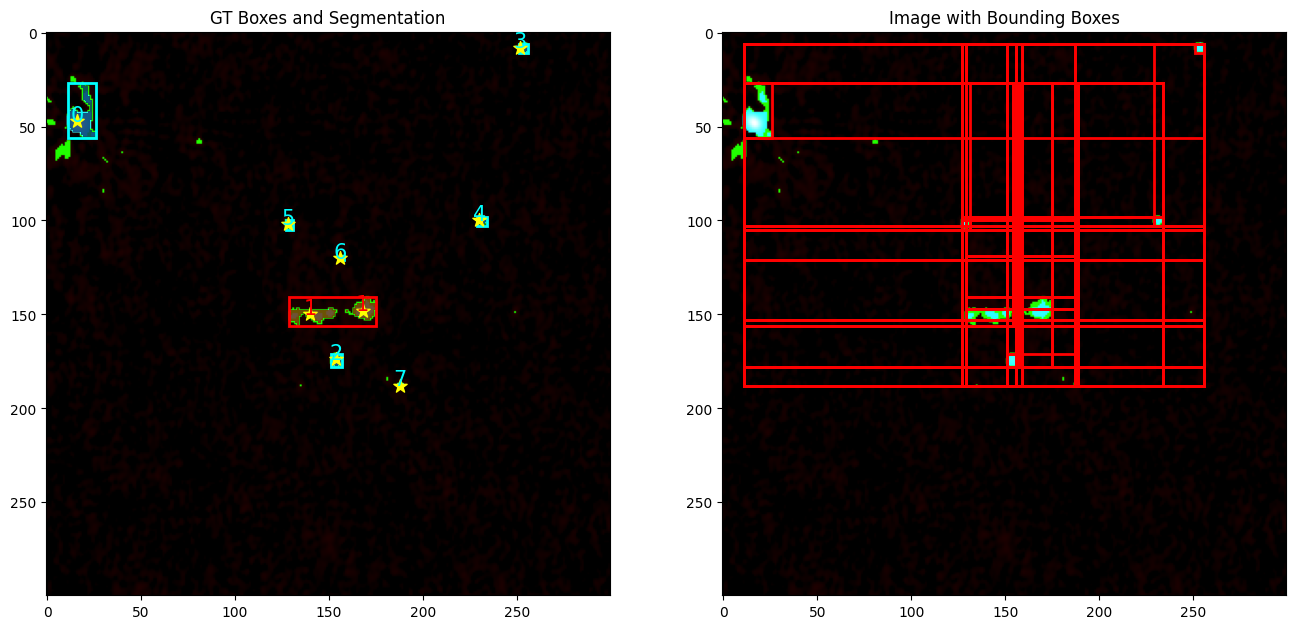

Plotting 255 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000133_rotated_angle90_RA164.012224_DEC54.215038.png


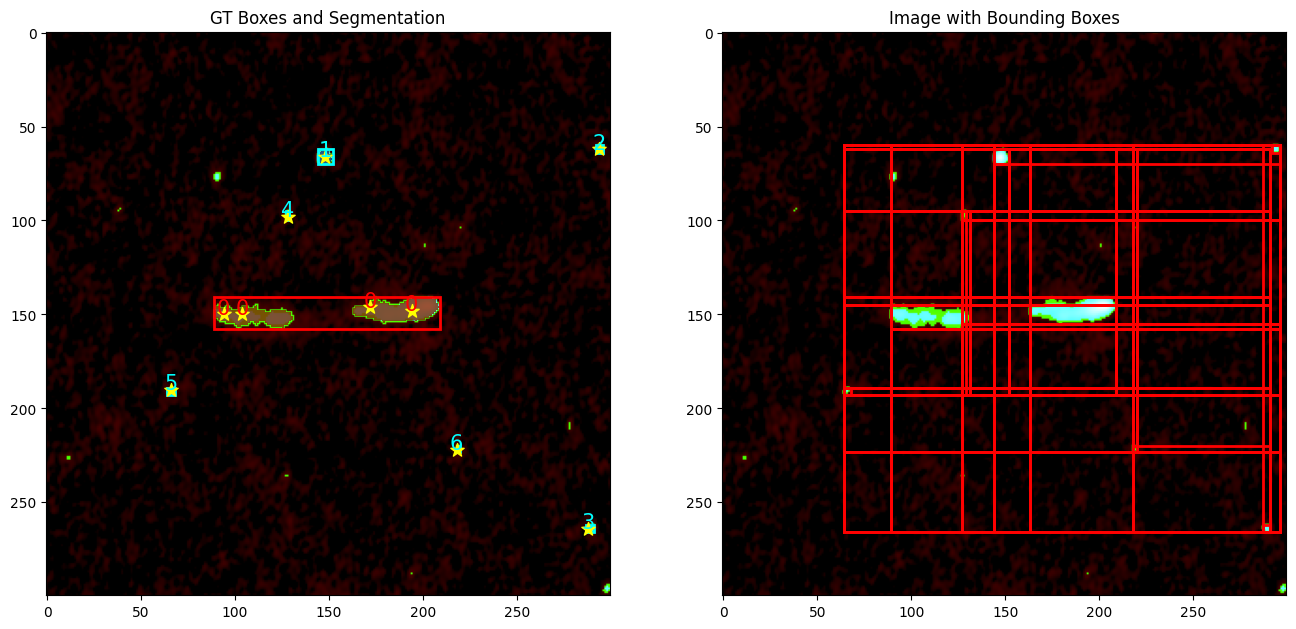

Plotting 127 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000068_rotated_angle90_RA163.110758_DEC55.541807.png


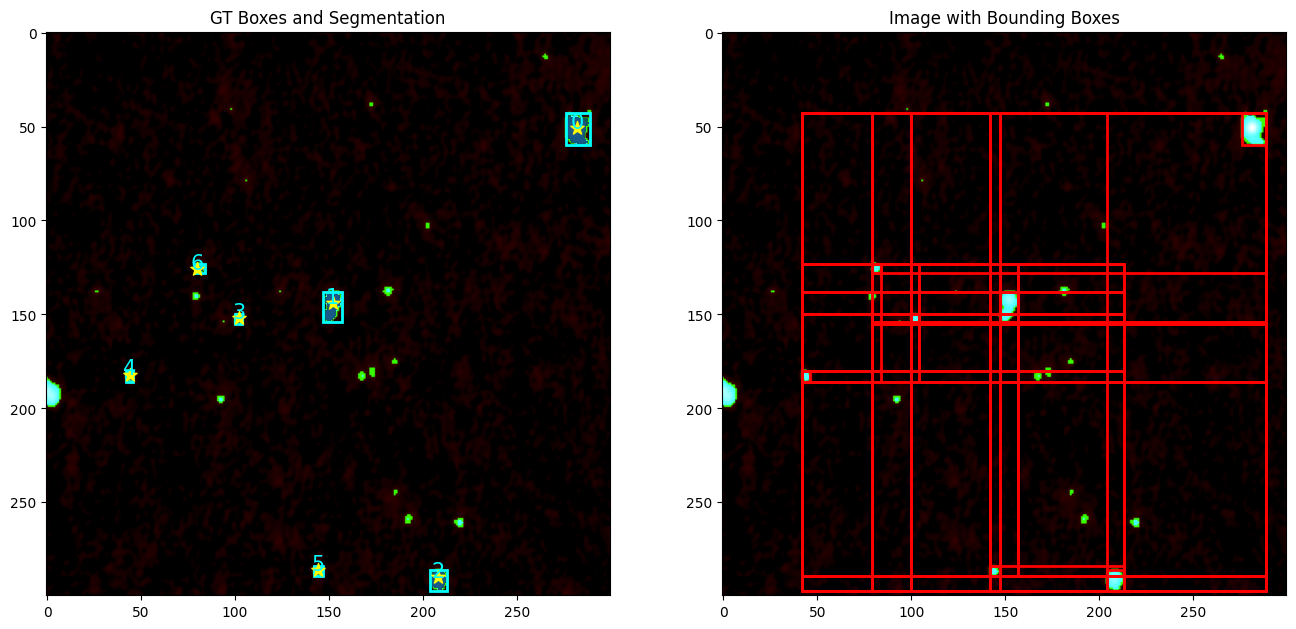

In [9]:
for image_id in images_to_inspect:
    plot_image_with_boxes_proposals(annotations, annotations_path, image_id)